# PPThinning\n\nSimulating point processes by thinning.\n\nPython port of the MATLAB `PPThinning` helpfile (`helpfiles/PPThinning.m`).

## Simulate PP via thinning

Given a conditional intensity function, we generate a point process consistent with this CIF.

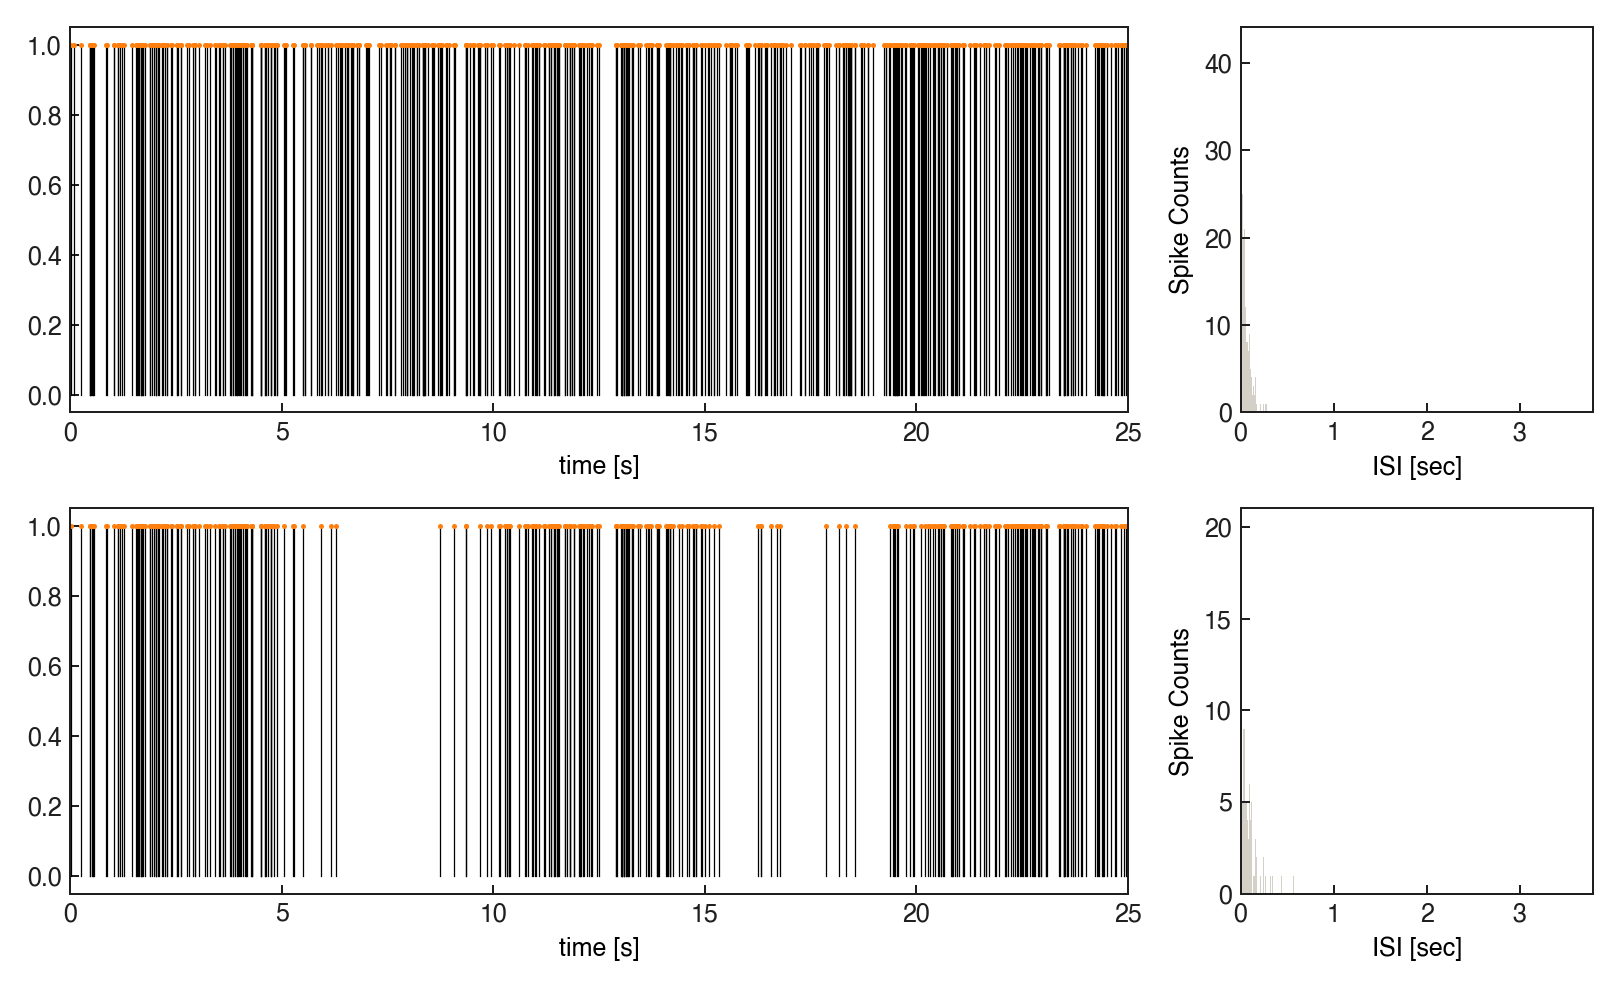

In [ ]:
# SECTION 1: Simulate PP via thinning
from pathlib import Path
import sys
REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from nstat import Covariate, nspikeTrain, nstColl, CIF
from nstat.notebook_figures import FigureTracker
np.random.seed(0)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic="PPThinning", output_root=OUTPUT_ROOT, expected_count=4)
def capture(label, fn):
    fig = __tracker.new_figure(label); plt.close(fig); fn(); __tracker._active_fig = plt.gcf()


## Basic Example

In [ ]:
# SECTION 2: Basic Example
delta = 0.001; Tmax = 100; time = np.arange(0, Tmax + delta, delta); f = 0.1
lambdaData = 10*np.sin(2*np.pi*f*time) + 10
lam = Covariate(time, lambdaData, "Lambda(t)", "time", "s", "Hz", ["lambda_1"])
lambdaBound = float(np.max(lambdaData))
rng = np.random.default_rng(0)
N = int(lambdaBound * 1.5 * Tmax)
u = rng.random(N); w = -np.log(u) / lambdaBound
tSpikes = np.cumsum(w); tSpikes = tSpikes[tSpikes <= Tmax]
ratio = np.asarray(lam.getValueAt(tSpikes)).flatten() / lambdaBound
u2 = rng.random(len(ratio)); tThin = tSpikes[ratio >= u2]

## Compare Constant rate process vs. thinned process

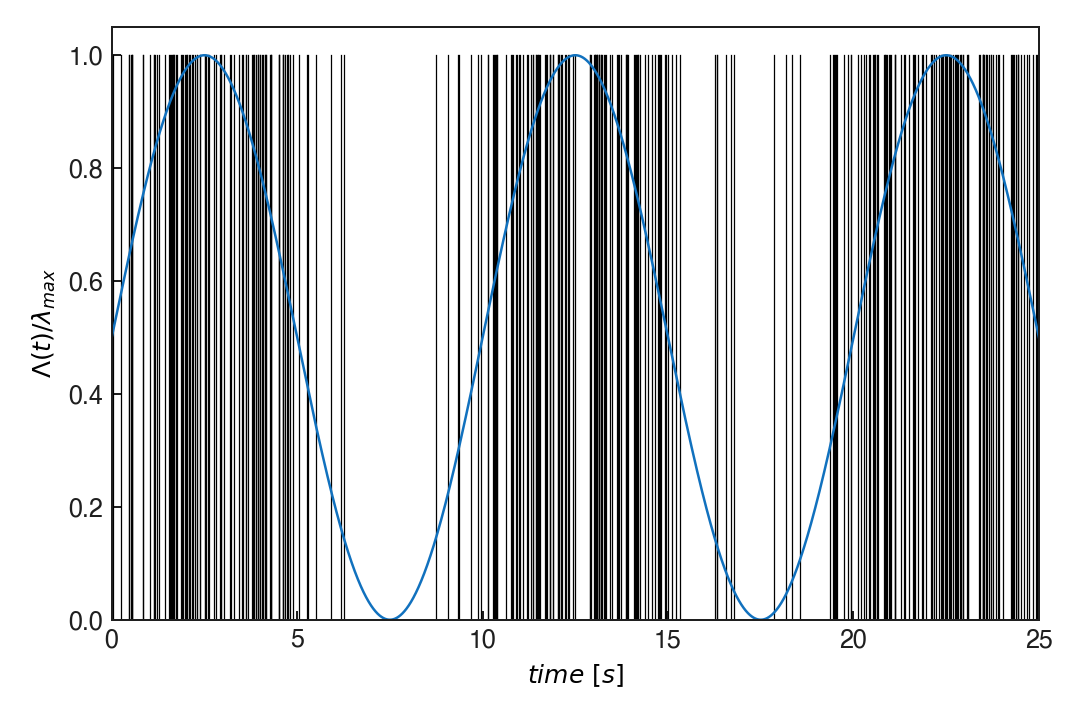

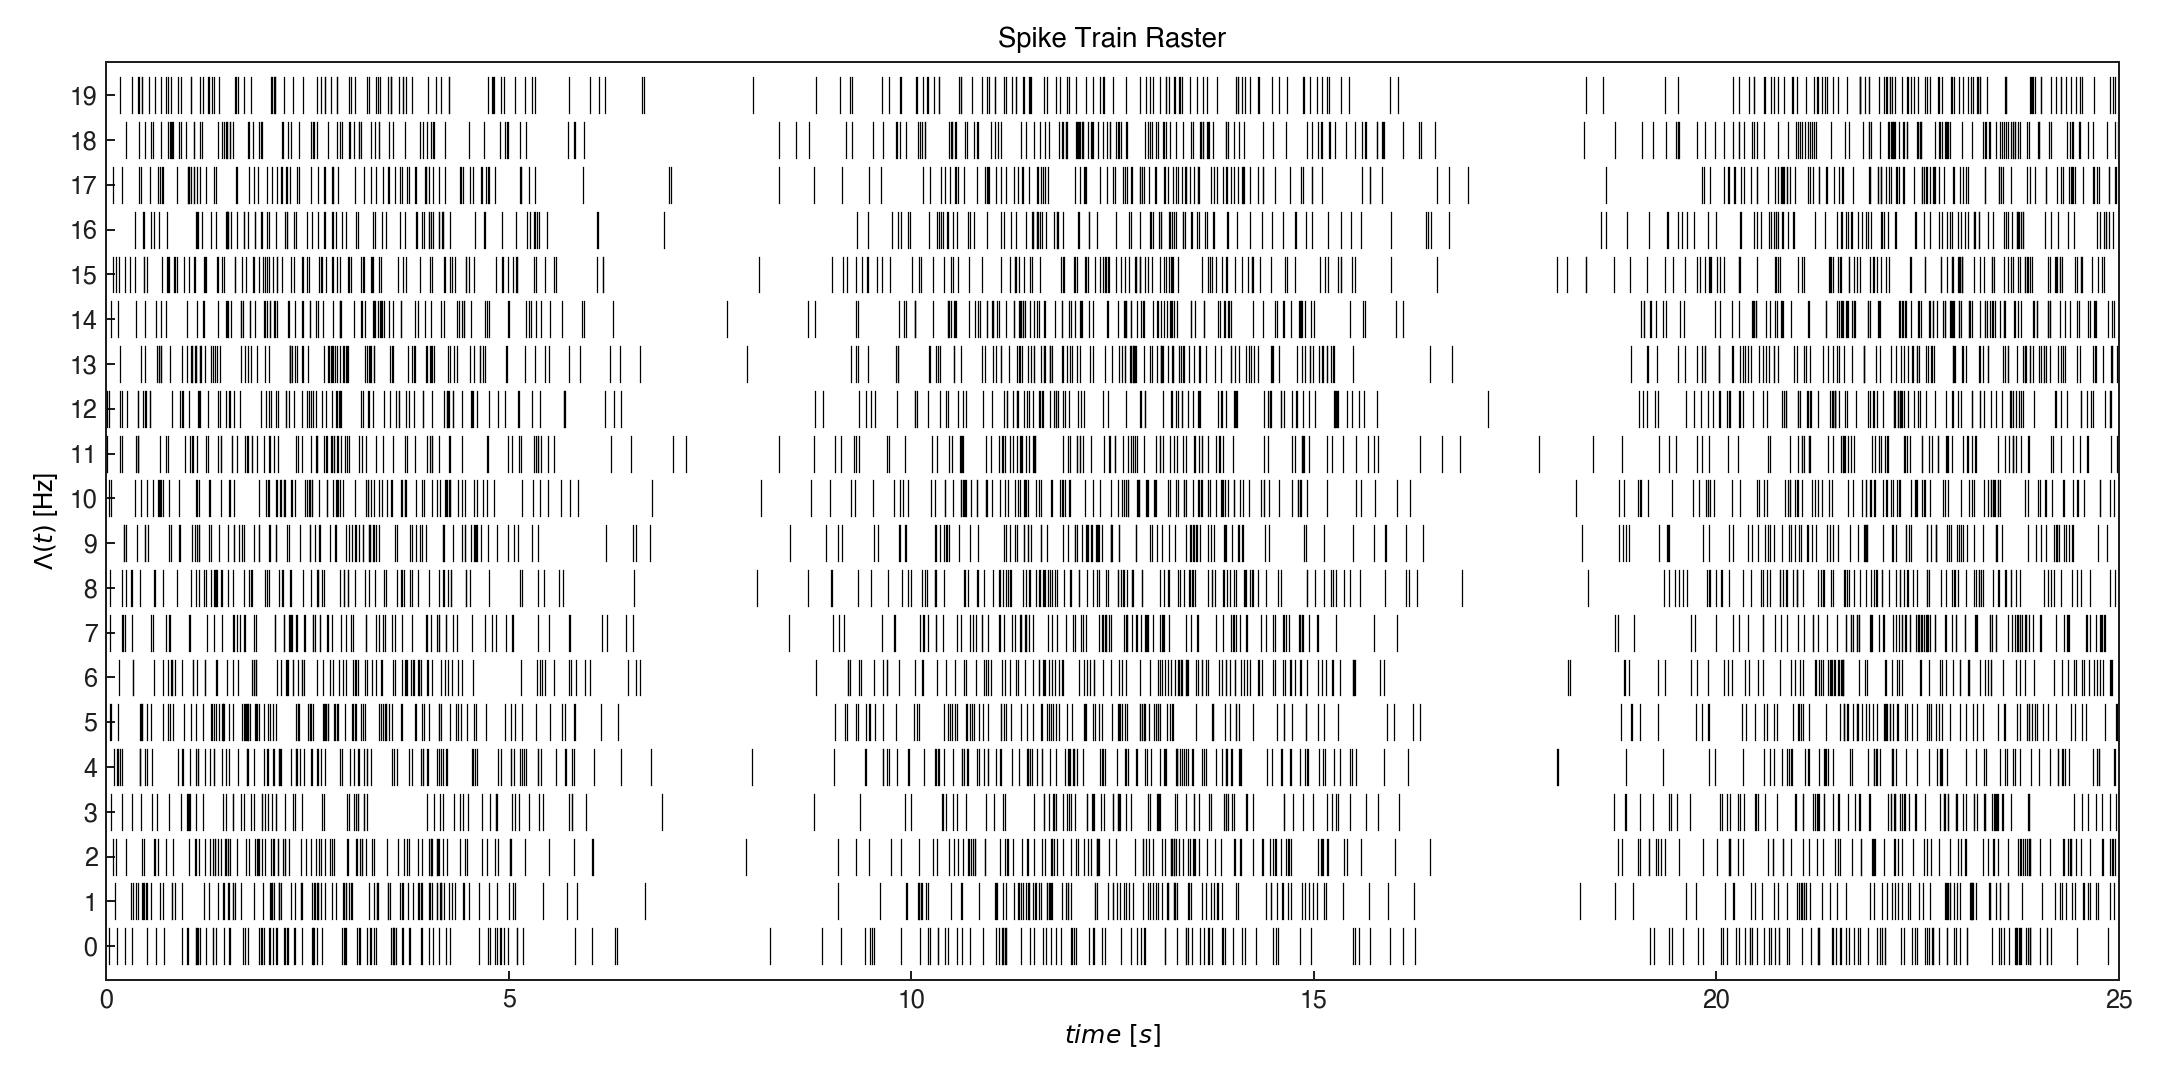

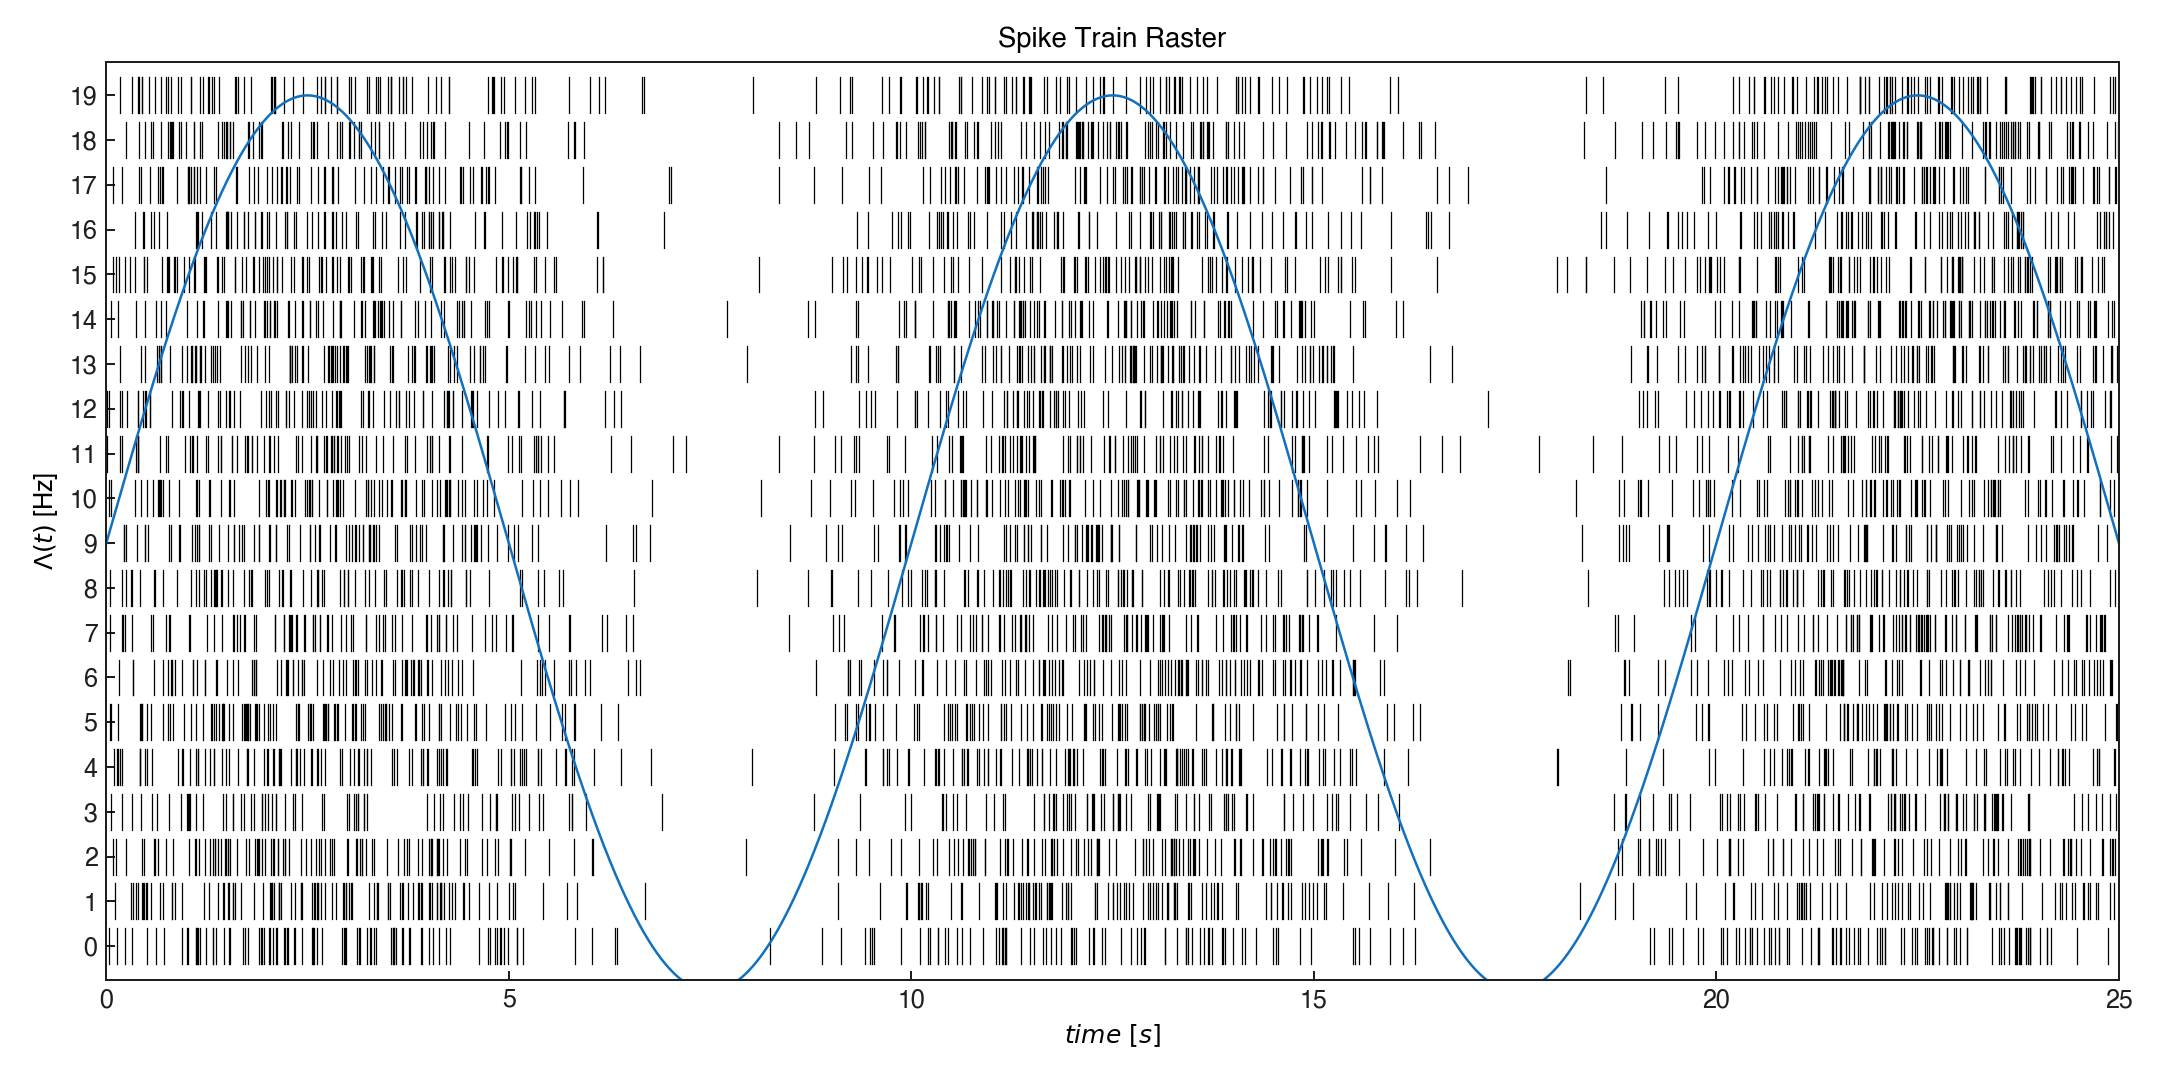

In [ ]:
# SECTION 3: Compare Constant rate process vs. thinned process
# Match MATLAB §3: n1 = nspikeTrain(tSpikes); n2 = nspikeTrain(tSpikesThin)
# happen inside this section, not the Basic Example section.
n1 = nspikeTrain(tSpikes); n2 = nspikeTrain(tThin)

def _start_fig(label, figsize=(8.0, 4.5)):
    # Open a tracker slot, then discard the placeholder axes/title cleanly so
    # nothing from the placeholder leaks into the saved PNG.
    fig = __tracker.new_figure(label)
    fig.clf()
    fig.set_size_inches(*figsize)
    __tracker._active_fig = fig
    __tracker._active_ax = None
    return fig

# Figure 1: 2 rows x 2 cols with width_ratios=[3,1] — raster wide, ISI hist narrow.
# Matches MATLAB layout where each row pairs a tall wide raster with a tight
# ISI histogram on the right. MATLAB calls n.plotISIHistogram directly, which
# uses the nSTAT default 1 ms bin width — mirror that here by delegating to
# nspikeTrain.plotISIHistogram(handle=ax) instead of inline plt.hist.
fig1 = _start_fig("constant-rate vs thinned process", figsize=(9.0, 5.5))
gs = fig1.add_gridspec(2, 2, width_ratios=[3, 1])
# Match MATLAB: use a common ISI x-limit across both ISI histograms so the
# constant-rate vs thinned process distributions are visually comparable, and
# reduce raster overlay marker size so the dotted spike-time row reads as a
# thin row of dots rather than a heavy band (MATLAB renders these as fine '.').
_isi1 = n1.getISIs(); _isi2 = n2.getISIs()
isi_xmax_match = float(max(np.max(_isi1) if _isi1.size else 0.0,
                            np.max(_isi2) if _isi2.size else 0.0))
# subplot(2,2,1): n1.plot; plot(tSpikes,ones(size(tSpikes)),'.'); v=axis; axis([0 Tmax/4 v(3) v(4)])
ax = fig1.add_subplot(gs[0, 0]); n1.plot(currentHandle=ax)
ax.plot(tSpikes, np.ones_like(tSpikes), '.', color='tab:orange', markersize=2)
ax.set_xlim(0, Tmax/4); ax.set_xlabel('time [s]')
# subplot(2,2,2): n1.plotISIHistogram
ax = fig1.add_subplot(gs[0, 1])
n1.plotISIHistogram(handle=ax)
ax.set_xlim(0, isi_xmax_match)
# subplot(2,2,3): n2.plot; plot(tSpikes,ones(size(tSpikes)),'.'); v=axis; axis([0 Tmax/4 v(3) v(4)])
ax = fig1.add_subplot(gs[1, 0]); n2.plot(currentHandle=ax)
ax.plot(tThin, np.ones_like(tThin), '.', color='tab:orange', markersize=2)
ax.set_xlim(0, Tmax/4); ax.set_xlabel('time [s]')
# subplot(2,2,4): n2.plotISIHistogram
ax = fig1.add_subplot(gs[1, 1])
n2.plotISIHistogram(handle=ax)
ax.set_xlim(0, isi_xmax_match)
fig1.tight_layout()

# Figure 2: thinned spikes + scaled rate p(t) — single panel matching MATLAB's
# squarish portrait aspect. MATLAB renders the raster via n2.plot and the
# scaled rate via a Covariate (scaledProb = lambda * (1/lambdaBound)) .plot —
# mirror that here by delegating to the nspikeTrain / Covariate plotting paths
# instead of inline vlines + plt.plot.
fig2 = _start_fig("thinned spikes + scaled rate", figsize=(6.0, 4.0))
ax2 = fig2.add_subplot(1,1,1)
n2.plot(currentHandle=ax2)
scaledProb = Covariate(time, lambdaData / lambdaBound, "Lambda(t)", "time", "s", "Hz", ["lambda_1"])
scaledProb.plot(handle=ax2)
ax2.set_xlim(0, Tmax/4); ax2.set_ylim(0, 1.05)
ax2.set_xlabel(r'$time\ [s]$'); ax2.set_ylabel(r'$\Lambda(t)/\lambda_{max}$')
# Match MATLAB's integer-second x-ticks (0, 5, 10, 15, 20, 25).
from matplotlib.ticker import MultipleLocator as _MultipleLocator, FormatStrFormatter as _FormatStrFormatter
ax2.xaxis.set_major_locator(_MultipleLocator(5))
ax2.xaxis.set_major_formatter(_FormatStrFormatter('%d'))
# MATLAB does not render a legend on this panel — suppress the empty/auto
# legend the Covariate.plot path adds so the figure matches MATLAB exactly.
_leg = ax2.get_legend()
if _leg is not None:
    _leg.remove()
fig2.tight_layout()

## Simulate multiple realizations of a point process via thinning

The CIF class can generated realizations of a point process given a conditional intensity function (defined as a Covariate or SignalObj)

In [ ]:
# SECTION 4: Simulate multiple realizations of a point process via thinning
spikeColl = CIF.simulateCIFByThinningFromLambda(lam, 20, seed=1)

# Figure 3: ensemble raster only — mirrors MATLAB MLX snapshot taken after
# spikeColl.plot but before lambda.plot is overlaid (PPThinning_03.png).
fig3 = _start_fig("20 thinning realizations (raster only)", figsize=(12.0, 6.0))
ax3 = fig3.add_subplot(1,1,1)
spikeColl.plot(handle=ax3)
ax3.set_xlim(0, Tmax/4)
ax3.set_xlabel(r'$time\ [s]$')
ax3.set_ylabel(r'$\Lambda(t)$ [Hz]')

# Figure 4: ensemble raster + lambda(t) overlay — mirrors MATLAB MLX snapshot
# taken after lambda.plot is overlaid on the same axis (PPThinning_04.png).
fig3b = _start_fig("20 thinning realizations + rate", figsize=(12.0, 6.0))
ax3b = fig3b.add_subplot(1,1,1)
spikeColl.plot(handle=ax3b)
lam.plot(handle=ax3b)
ax3b.set_xlim(0, Tmax/4)
ax3b.set_xlabel(r'$time\ [s]$')
ax3b.set_ylabel(r'$\Lambda(t)$ [Hz]')

__tracker.finalize()